# Week 3 시계열 데이터 과제_25기 이유민

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA 모델 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1. 시계열 데이터에서 정상성이 중요한 이유는 통계적 추론의 안정성 때문입니다. 평균과 분산이 시간에 따라 일정해야 과거의 패턴이 미래에도 동일하게 반복된다는 가정이 성립하며, 이를 통해 신뢰할 수 있는 예측 모델을 구축할 수 있습니다.  만약 데이터가 비정상적이라면 모델의 파라미터가 시간에 따라 변하게 되어 예측력이 급격히 떨어집니다.

ARIMA 모델은 이러한 비정상성을 처리하기 위해 차분(Differencing)을 사용합니다. 현재 시점의 값에서 이전 시점의 값을 빼주는 과정을 통해 데이터의 추세나 계절성을 제거하고 평균을 일정하게 만듭니다. 이렇게 정상화된 데이터에 과거 값의 영향력을 반영하는 자기회귀(AR)와 과거 오차를 반영하는 이동평균(MA) 결합 모델을 적용하여 미래를 예측합니다.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2. 해당 시계열은 비정상 시계열입니다. 원 시계열의 ACF가 매우 천천히 감소하는 것은 데이터에 일정한 평균으로 회귀하지 않는 강한 추세가 존재함을 의미하는 전형적인 비정상성 특징이기 때문입니다. 이 데이터를 분석하기 위한 적절한 모형은 ARIMA(0, 1, q) 또는 IMA(1, q)입니다.

## 실습: ARIMA  
- **ARIMA** 모델 실습입니다. 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)로, 아래 코드를 통해 간단하게 불러올 수 있습니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smid80/weatherww2")

print("Path to dataset files:", path)

100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]

Extracting files...
Path to dataset files: C:\Users\yoomi\.cache\kagglehub\datasets\smid80\weatherww2\versions\1


In [5]:
# kaggle 기본 제공 코드
import os

path = kagglehub.dataset_download("smid80/weatherww2")

print("실제 저장 경로:", path)
print("파일 목록:", os.listdir(path))

실제 저장 경로: C:\Users\yoomi\.cache\kagglehub\datasets\smid80\weatherww2\versions\1
파일 목록: ['Summary of Weather.csv', 'Weather Station Locations.csv']


In [6]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_file_path = os.path.join(path, "Weather Station Locations.csv")
loc_df = pd.read_csv(loc_file_path)
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [7]:
# station별 실제 날씨 데이터
weather_file_path = os.path.join(path, "Summary of Weather.csv")
weather_df = pd.read_csv(weather_file_path)

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 수치형 값으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

C:\Users\yoomi\AppData\Local\Temp\ipykernel_26828\329226695.py:3: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(weather_file_path)


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [8]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

C:\Users\yoomi\AppData\Local\Temp\ipykernel_26828\3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
C:\Users\yoomi\AppData\Local\Temp\ipykernel_26828\3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


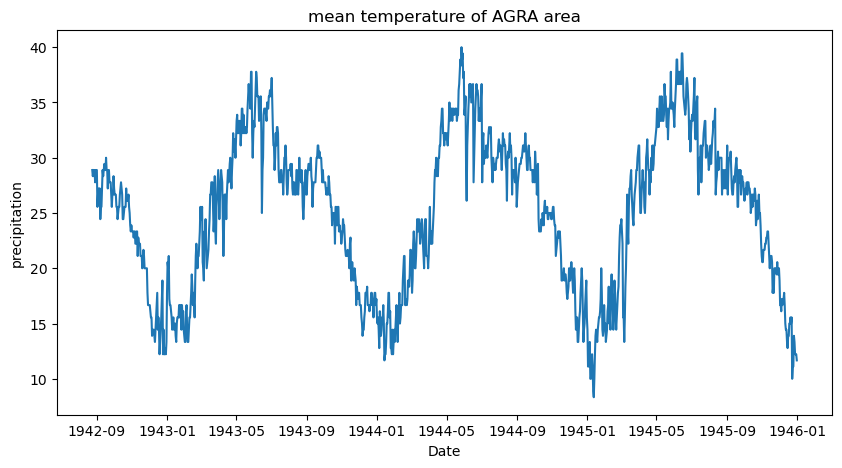

In [9]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [10]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

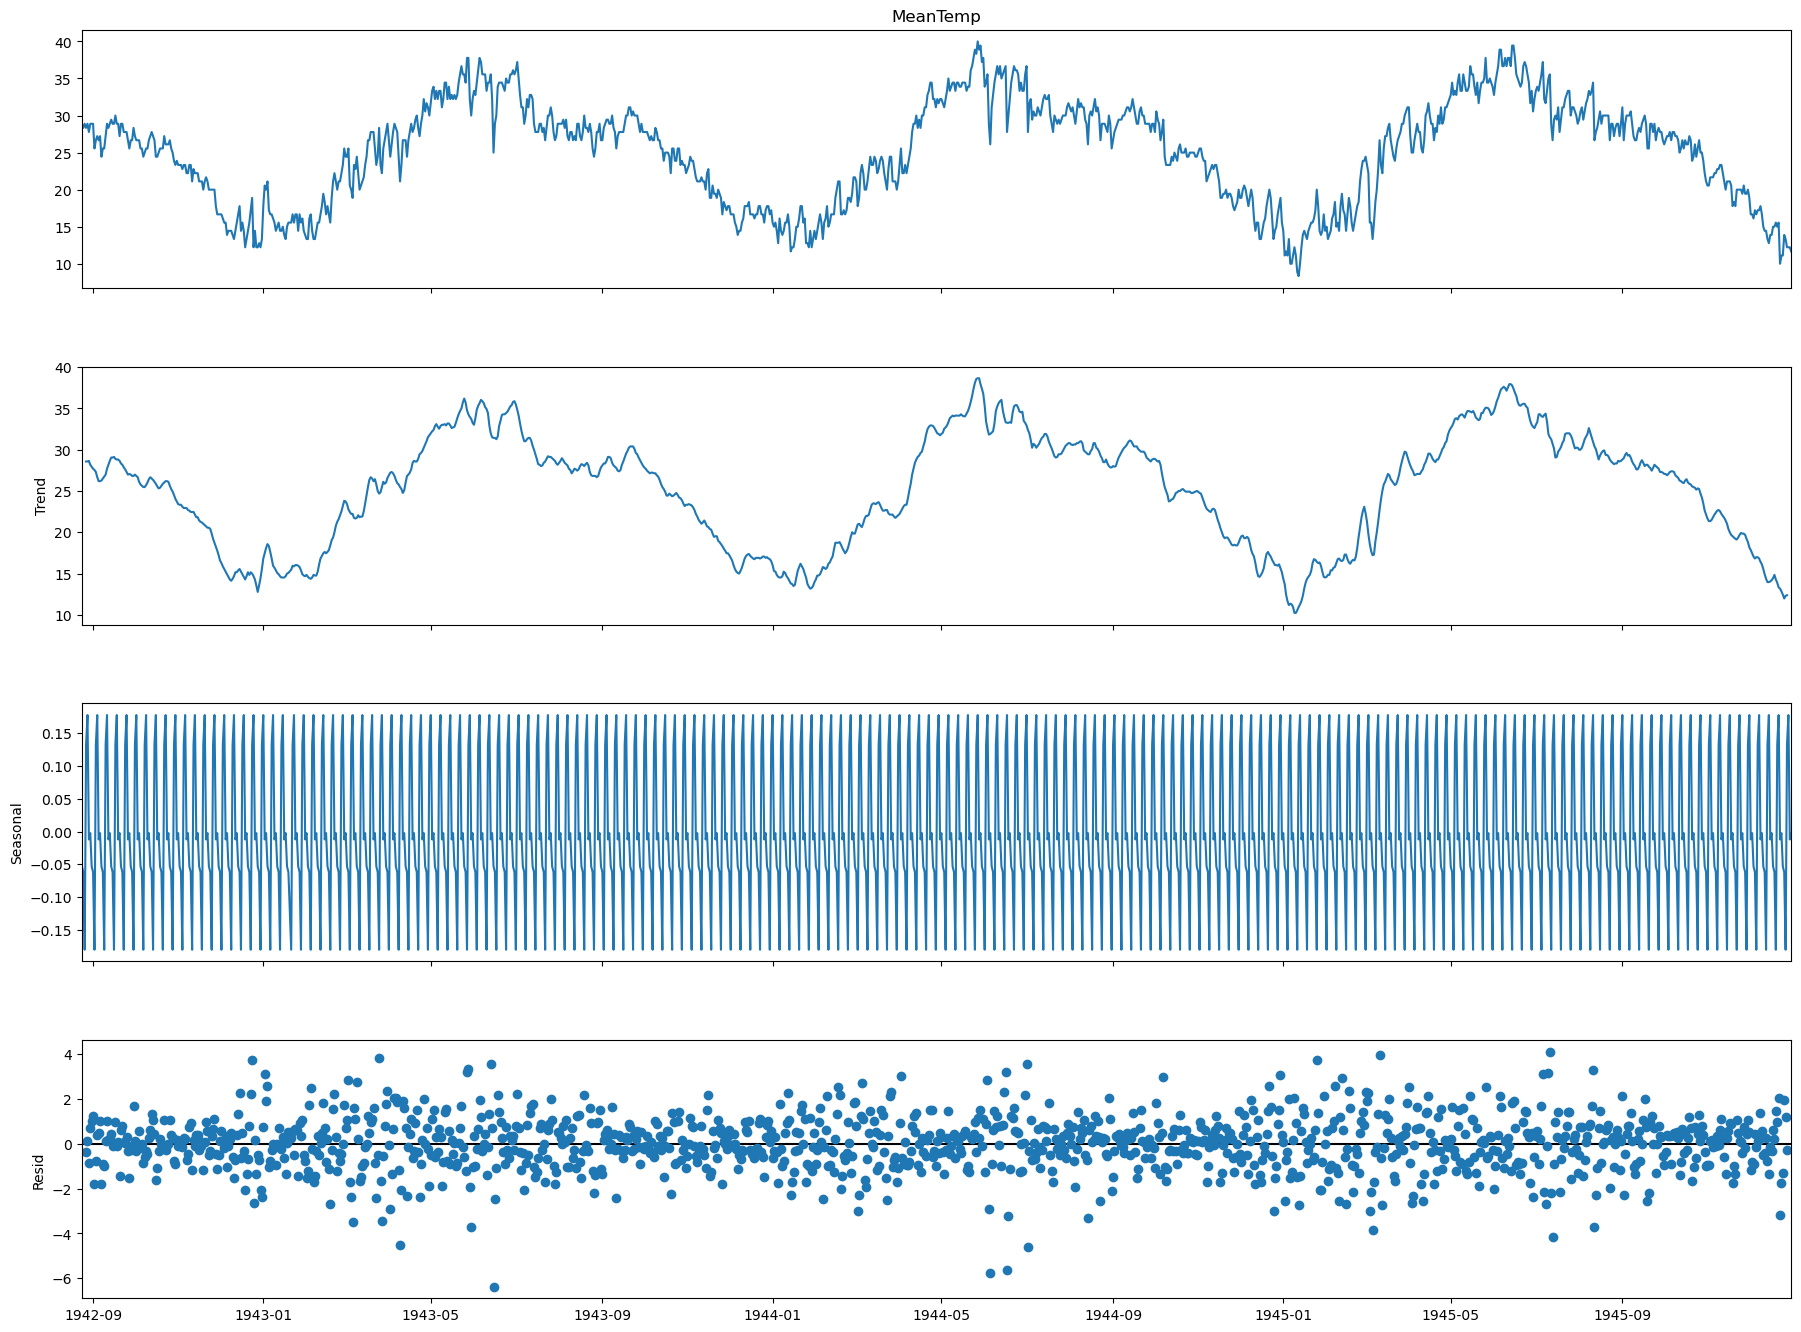

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

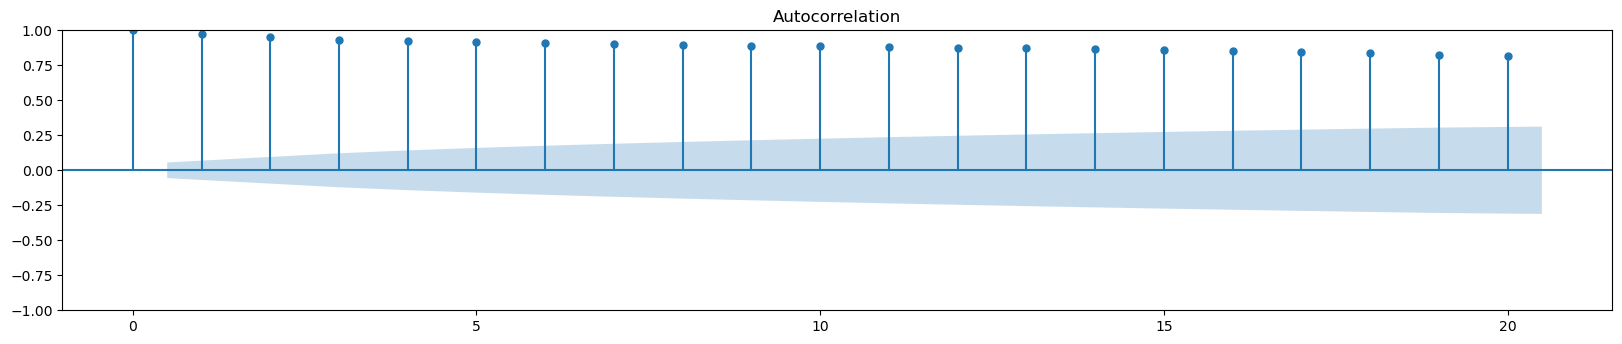

In [12]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [13]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설과 귀무가설이라는 키워드를 사용하여 서술하세요.

A1. 현재 분석 결과인 p-value(0.259)가 일반적인 유의수준인 0.05보다 훨씬 크고, ADF 통계량(-2.06) 역시 모든 임계값보다 높은 수치를 보이고 있습니다.  이는 통계적으로 유의미한 수준에서 귀무가설을 기각할 수 없음을 뜻하며, 결과적으로 해당 데이터는 비정상(Non-stationary) 시계열로 판단됩니다.

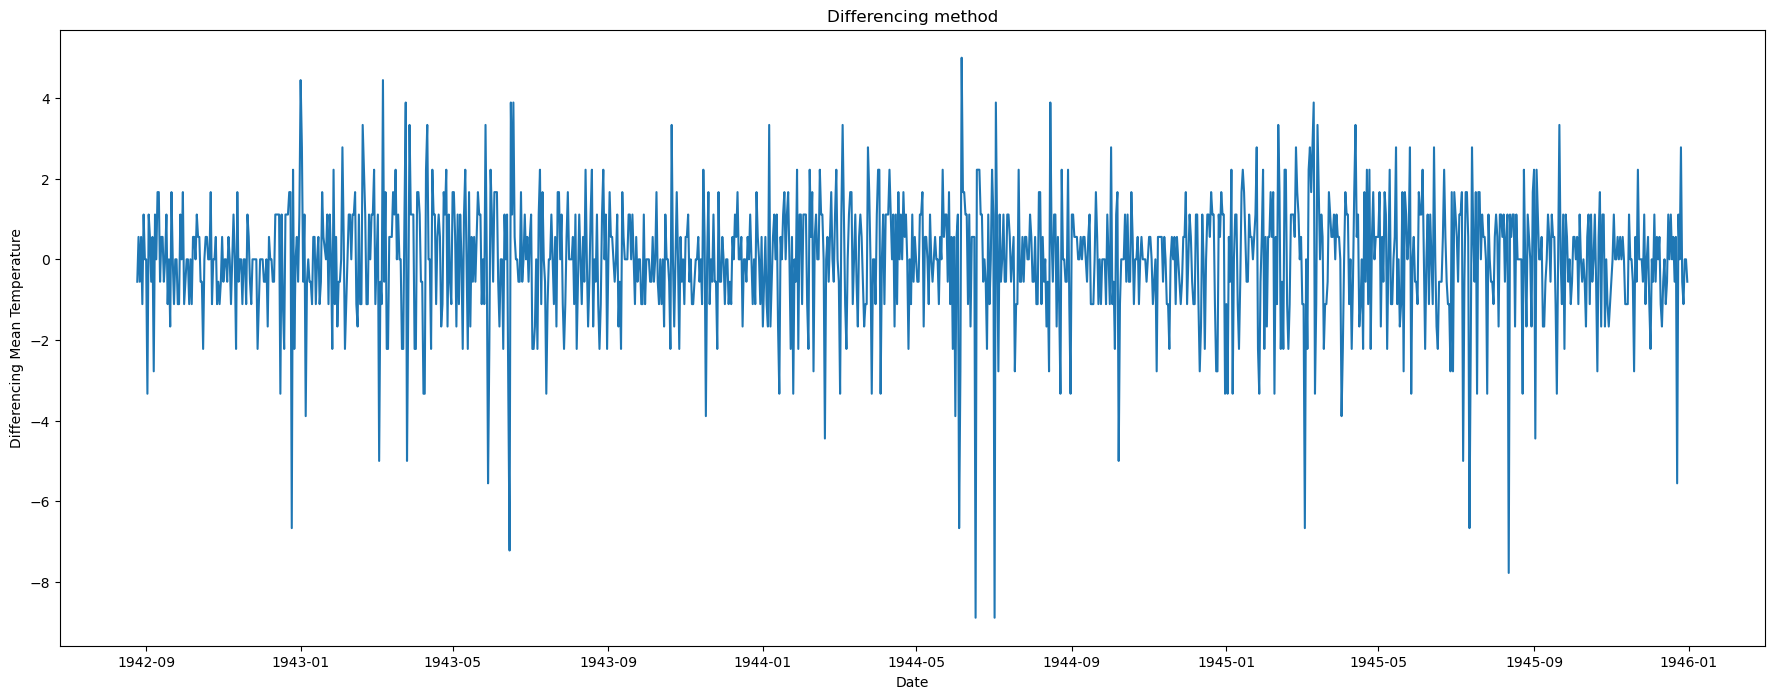

In [14]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [15]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2. 
1차 차분을 적용한 결과, 이전과 비교했을 때 p-value가 0.000으로 낮아지고 ADF 통계량(-6.29)이 임계값보다 훨씬 작아지면서 데이터가*정상*을 확보하게 되었습니다  이러한 변화가 발생한 이유는 차  연산이 시계열 내에 존재하던 시간적 추)를 효과적으로 제거했기 때문입니다.  현재 값에서 직전 값을 빼주는 과정을 통해 시간에 따라 변하던 데이터의 평균이 일정하게 유지되도록 안정화되었으며, 결과적으로 모델 학습과 예측에 적합한 정상 시계열 상태로 전환된 것입니다.

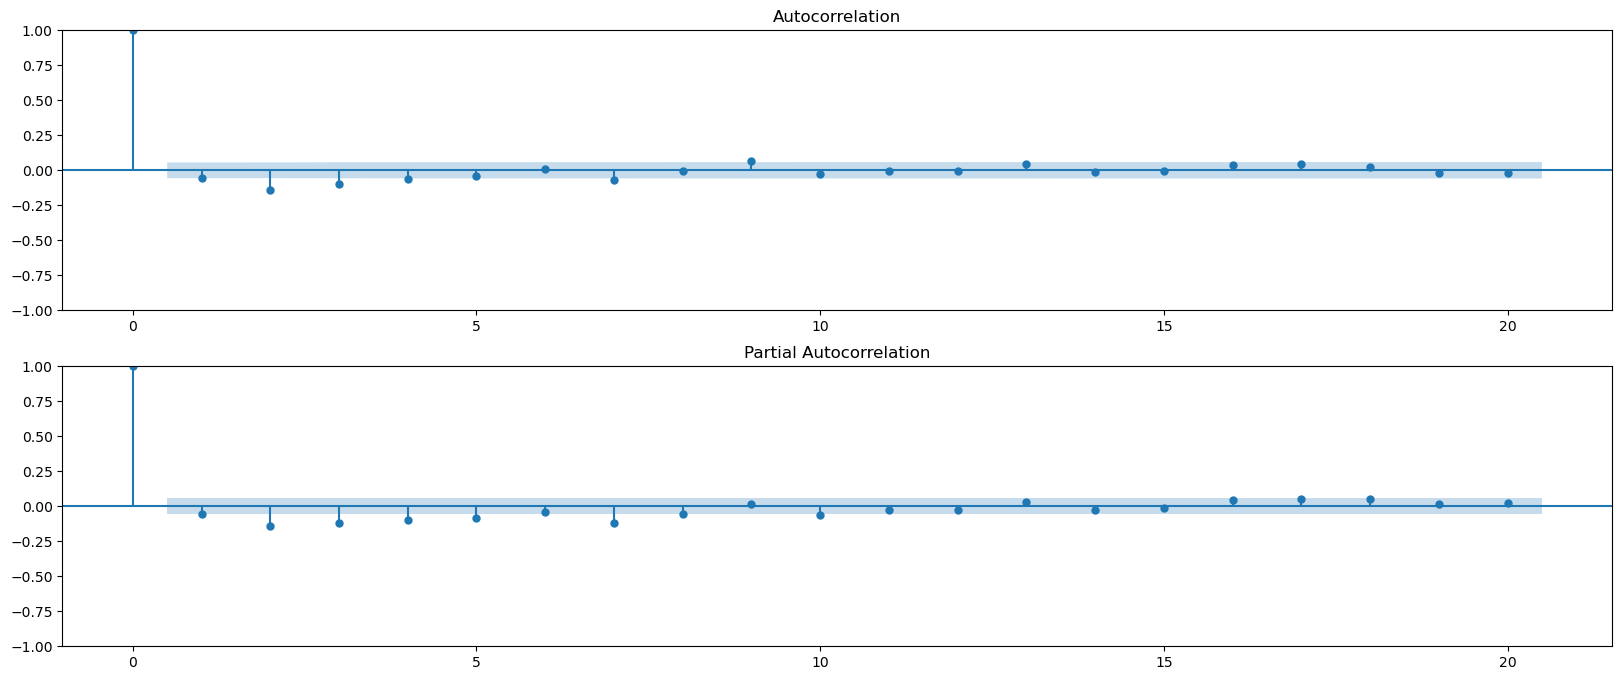

In [16]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3. 제시된 ACF(자기상관함수)와 PACF(부분자기상관함수) 그래프는 차분된 시계열 데이터의 상관관계를 시각화하여 ARIMA 모델의 적절한 차수를 결정하는 기준이 됩니다.
그래프를 분석하면 ACF와 PACF 모두 첫 번째 시차(Lag 1)부터 신뢰구간(파란색 음영 영역) 안으로 급격히 수렴하며 절단된 형태를 보이고 있습니다. 이는 데이터 간의 직간접적인 상관성이 매우 낮음을 의미하며, 시계열이 이전 시점의 값(AR)이나 오차항(MA)에 큰 영향을 받지 않는 화이트 노이즈(White Noise)에 가까운 상태임을 시사합니다. 따라서 하이퍼파라미터$)와$)는 모두 0으로 설정하는 것이 가장 적절합니다. 근거는 두 그래프 모두 유의미한 상관관계를 보이는 시차가 존재하지 않아 추가적인 자기회귀나 이동평균 성분을 반영할 필요가 없기 때문입니다. 이미 1차 차분을 통해 정상성을 완벽히 확보했으므로 모델은 ARIMA(0, 1, 0델의 형태가 됩니다.

### ARIMA

C:\Users\yoomi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\yoomi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\yoomi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


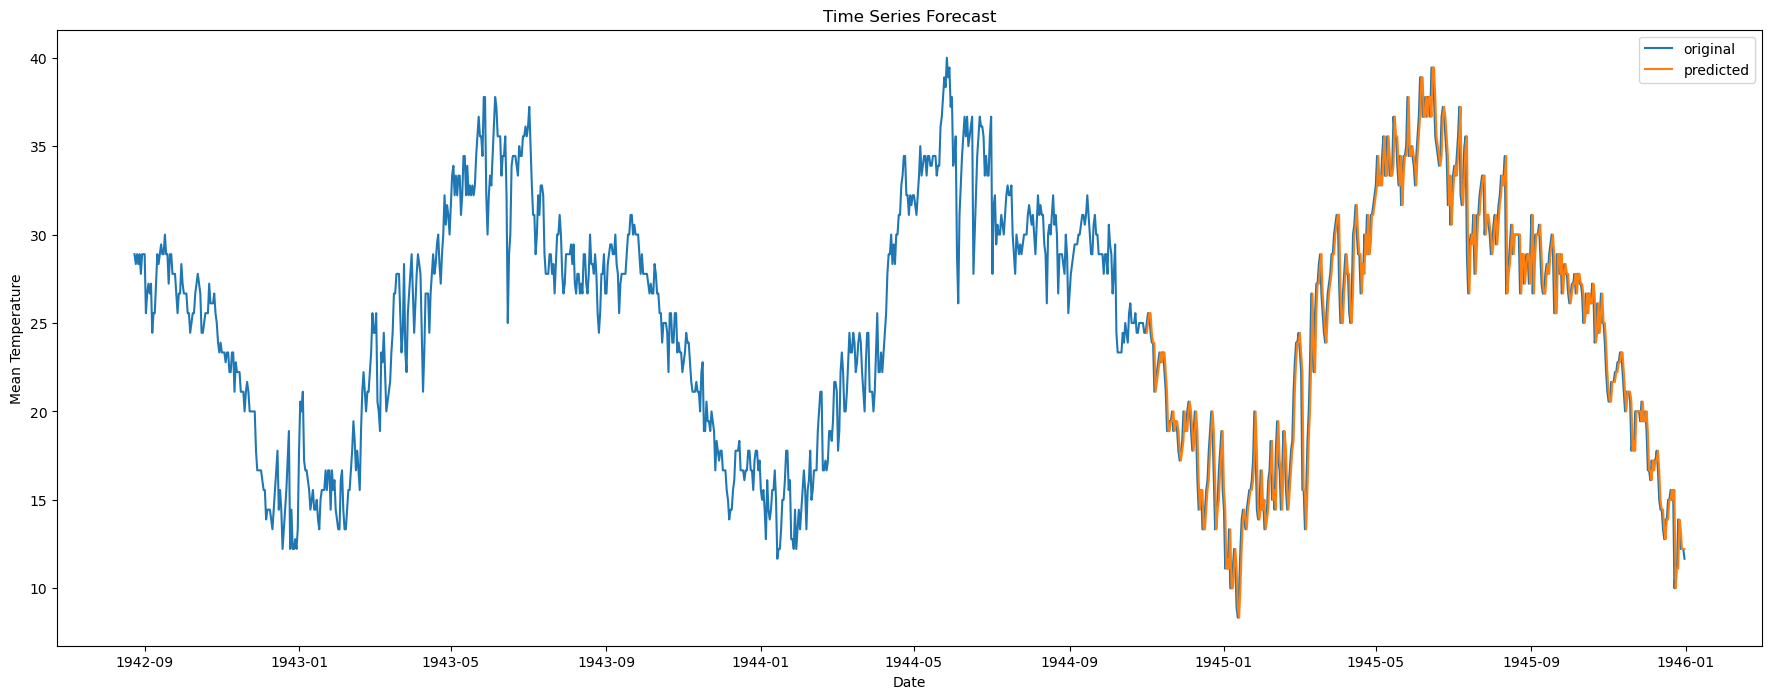

In [17]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 0
d = 1
q = 0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


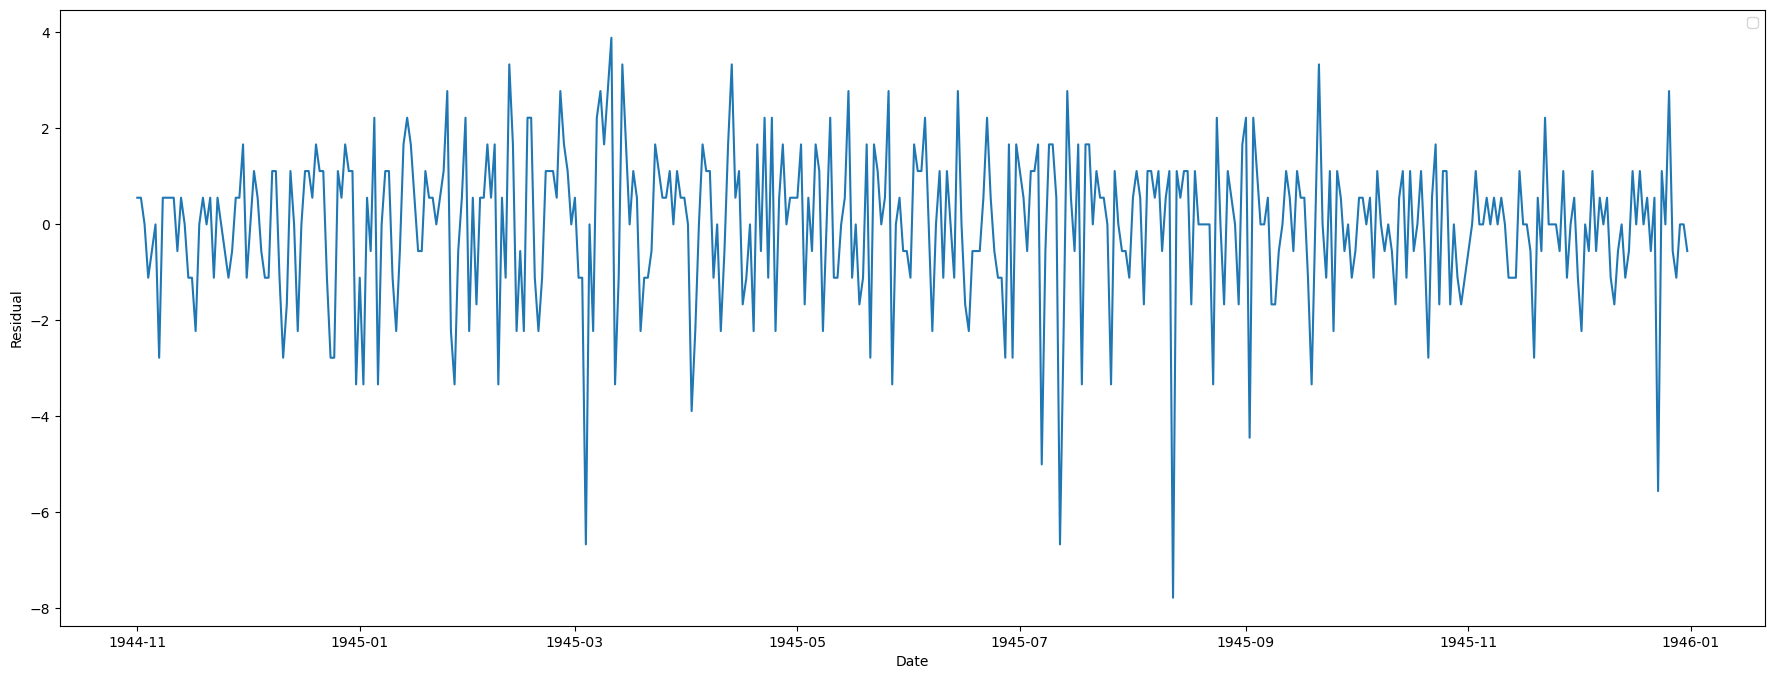

In [18]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

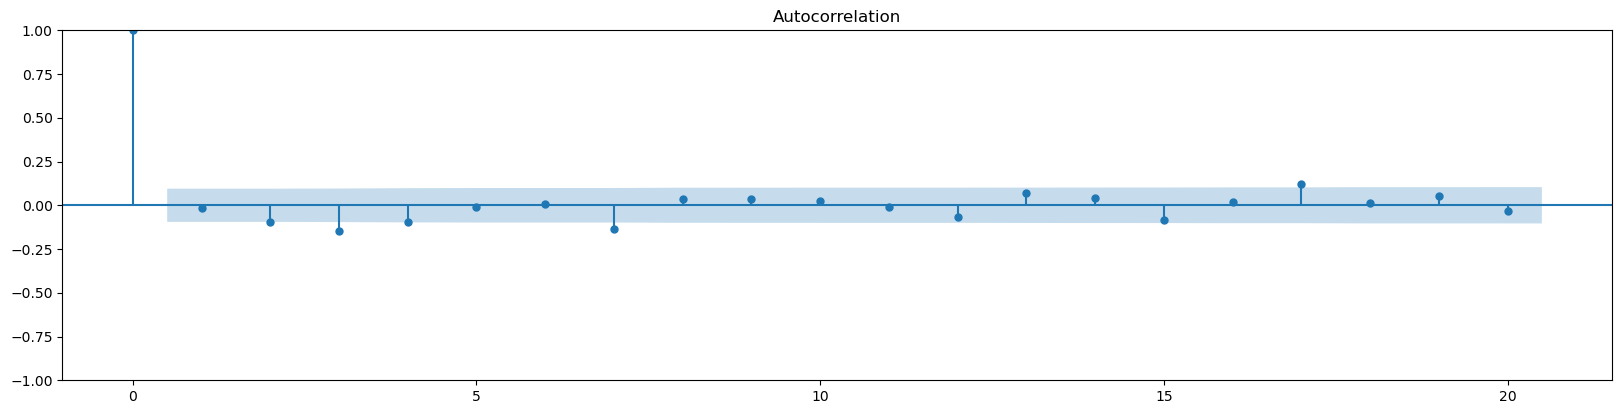

In [19]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [20]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.375983
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [21]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  # mae = round(metrics.mean_absolute_error(y_true, y_pred), 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [22]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.56,0.978,1.565,5.366


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4. R^2와 상관계수가 1에 매우 근접하여 모델의 설명력이 압도적으로 높으며, MAPE가 5% 내외라는 점은 평균적인 예측 오차가 매우 적은 정교한 모델임을 의미합니다. 

## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [23]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

NAME
ACCRA                1157
AGRA                 1225
AMBERLY               848
AMURI/FIELD AAF       884
ATAR                  876
                     ... 
TINDOUF               818
VAL DE CANS          1188
WALLER/BWI           1631
WHEELER/AFB 810.1    2192
WILLEMSTAD           1218
Length: 64, dtype: int64

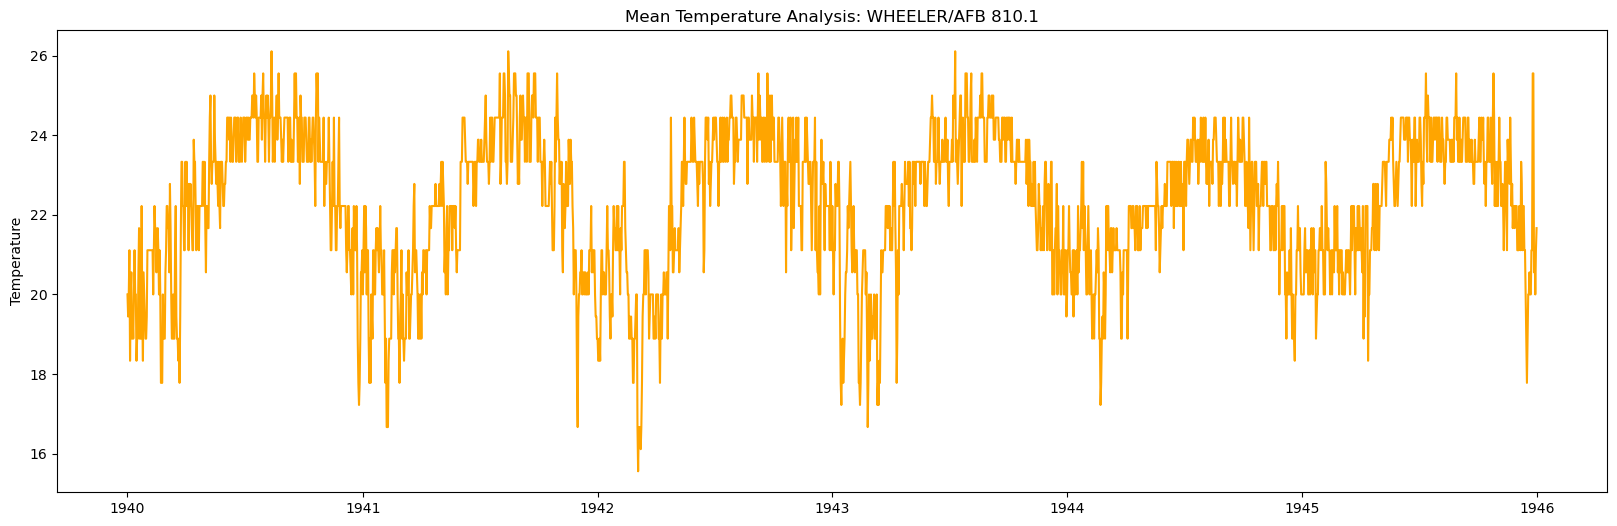

ADF Statistic: -3.423749
p-value: 0.010175


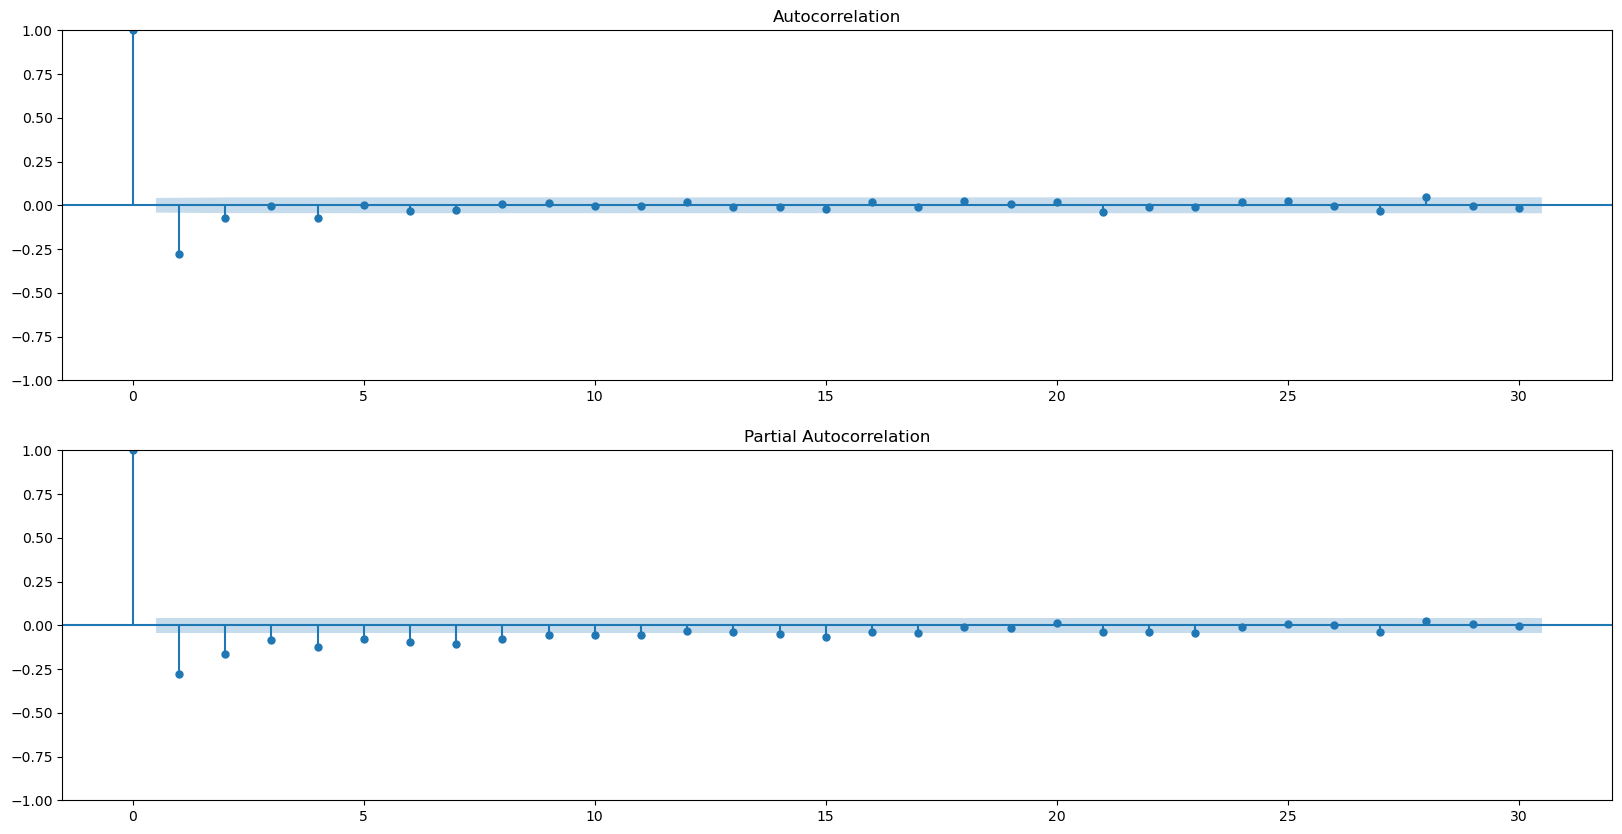

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# 1. WHEELER/AFB 810.1 데이터 추출 및 전처리
target_city = 'WHEELER/AFB 810.1'
wheeler_df = merged[merged['NAME'] == target_city].copy()
wheeler_df['Date'] = pd.to_datetime(wheeler_df['Date'])
wheeler_df.sort_values('Date', inplace=True)
wheeler_df.set_index('Date', inplace=True)

# 2. 평균 기온(MeanTemp) 시각화
ts_wheeler = wheeler_df['MeanTemp']
plt.figure(figsize=(20, 6))
plt.plot(ts_wheeler, color='orange')
plt.title(f"Mean Temperature Analysis: {target_city}")
plt.ylabel("Temperature")
plt.show()

# 3. 정상성 검정 (ADF Test)
result = adfuller(ts_wheeler.dropna())
print(f'ADF Statistic: {result[0]:.6f}')
print(f'p-value: {result[1]:.6f}')

# 4. 1차 차분 및 ACF/PACF 분석
ts_diff = ts_wheeler.diff().dropna()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
sm.graphics.tsa.plot_acf(ts_diff, lags=30, ax=ax1)
sm.graphics.tsa.plot_pacf(ts_diff, lags=30, ax=ax2)
plt.show()

WHEELER 지역의 기온 데이터는 2,000개 이상의 풍부한 샘플을 보유하고 있어 시계열 흐름이 매우 연속적이며, 초기 ADF 검정에서 나타난 비정상성을 1차 차분을 통해 효과적으로 제거하여 정상성을 확보했습니다.  이후 ACF와 PACF 그래프를 통해 시차 간의 유의미한 상관관계를 확인하며 최적의 ARIMA 파라미터를 결정할 수 있는 통계적 근거를 마련했습니다.실습 1의 AGRA 강수량 데이터와 비교했을 때, 기온 데이터는 물리적 관성에 의해 전날의 수치가 다음 날에 강한 영향을 미치는 연속적인 자기상관성이 뚜렷하게 나타납니다.  강수량은 비가 오지 않는 날(0)이 많아 데이터가 불연속적이고 변동성이 컸던 반면, 기온은 계절성과 연속성이 강해 ARIMA 모델을 통한 예측 정확도와 모델 설명력(R^2)이 훨씬 높게 도출되는 특성을 보입니다. 결론적으로 기상 요인 중 기온과 같이 물리적 연속성이 큰 지표일수록 시계열 분석을 통한 정교한 미래 예측에 더 유리함을 확인할 수 있었습니다.